In [1]:
# CELL 1 - SETUP: imports, random seed and output folders.
# Set USE_DRIVE = True if you want data/figures saved in Google Drive so they survive a Colab runtime reset.
import os, glob, zipfile, urllib.request, shutil
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from sklearn.model_selection import train_test_split

USE_DRIVE = False
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/CS3807_Exp6'
else:
    BASE_DIR = '/content/exp6'

DATA_DIR = os.path.join(BASE_DIR, 'data')
FIG_DIR  = os.path.join(BASE_DIR, 'figures')
RAW_DIR  = os.path.join(BASE_DIR, 'har_raw')
for d in (DATA_DIR, FIG_DIR, RAW_DIR):
    os.makedirs(d, exist_ok=True)

SEED = 42
print('Base folder:', BASE_DIR)

Base folder: /content/exp6


In [2]:
# CELL 2 - FONT + PLOT STYLE: installs Liberation Serif (metric-identical to Times New Roman), sets serif fonts
# everywhere, embeds fonts in EPS, and defines save_fig() which writes EPS (for LaTeX) + a PNG preview.
!apt-get -qq install -y fonts-liberation > /dev/null

for f in glob.glob('/usr/share/fonts/truetype/liberation*/LiberationSerif-*.ttf'):
    font_manager.fontManager.addfont(f)

available = {f.name for f in font_manager.fontManager.ttflist}
candidates = ['Times New Roman', 'Liberation Serif', 'Nimbus Roman', 'STIXGeneral']   # STIX ships with matplotlib
FONT = next((c for c in candidates if c in available), 'STIXGeneral')

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': [FONT],
    'mathtext.fontset': 'stix',          # math text also looks like Times
    'ps.fonttype': 42, 'pdf.fonttype': 42,   # embed TrueType fonts in EPS/PDF
    'axes.unicode_minus': False,         # avoids missing minus glyph in EPS
    'font.size': 10, 'axes.labelsize': 11, 'axes.titlesize': 11,
    'legend.fontsize': 9, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'axes.grid': True, 'grid.linestyle': ':', 'grid.linewidth': 0.5,
})

def save_fig(fig, name):
    """Save as EPS (no transparency - EPS does not support it) and PNG preview, then show inline."""
    eps_path = os.path.join(FIG_DIR, f'{name}.eps')
    png_path = os.path.join(FIG_DIR, f'{name}.png')
    fig.savefig(eps_path, format='eps', bbox_inches='tight')
    fig.savefig(png_path, format='png', dpi=200, bbox_inches='tight')
    plt.show()
    print('Saved:', eps_path)

print('Using font:', FONT)

Using font: Liberation Serif


In [3]:
# CELL 3 - CONFIGURATION: dataset URL, channel/class names, subset size, and which classes/channels go into Plot 1.
# N_PER_CLASS = 500 gives 6 x 500 = 3000 windows (lab recommends 1500-3000). Use None for the full training partition.
N_PER_CLASS = 500
URL = ('https://archive.ics.uci.edu/static/public/240/'
       'human+activity+recognition+using+smartphones.zip')

SIGNALS = ['body_acc_x', 'body_acc_y', 'body_acc_z',
           'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
           'total_acc_x', 'total_acc_y', 'total_acc_z']
CLASS_NAMES = ['WALKING', 'WALKING UPSTAIRS', 'WALKING DOWNSTAIRS',
               'SITTING', 'STANDING', 'LAYING']

PLOT_CLASSES  = [0, 3, 5]      # WALKING, SITTING, LAYING (need >= 3 classes)
PLOT_CHANNELS = [0, 3, 6]      # body_acc_x, body_gyro_x, total_acc_x (need >= 3 channels)
CHANNEL_LABELS = {0: 'Body acceleration x (g)',
                  3: 'Body gyroscope x (rad/s)',
                  6: 'Total acceleration x (g)'}

In [4]:
# CELL 4 - DOWNLOAD DATASET: downloads and unzips the UCI HAR dataset (handles the nested zip inside the archive).
def find_root():
    hits = glob.glob(os.path.join(RAW_DIR, '**', 'UCI HAR Dataset'), recursive=True)
    return hits[0] if hits else None

def ensure_dataset():
    root = find_root()
    if root:
        return root
    zip_path = os.path.join(RAW_DIR, 'har.zip')
    if not os.path.exists(zip_path):
        print('Downloading UCI HAR dataset ...')
        urllib.request.urlretrieve(URL, zip_path)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(RAW_DIR)
    for nested in glob.glob(os.path.join(RAW_DIR, '**', '*.zip'), recursive=True):
        if nested != zip_path and 'UCI HAR' in os.path.basename(nested):
            with zipfile.ZipFile(nested) as z:
                z.extractall(RAW_DIR)
    root = find_root()
    if root is None:
        raise FileNotFoundError("'UCI HAR Dataset' folder not found. Upload it manually into " + RAW_DIR)
    return root

ROOT = ensure_dataset()
print('Dataset folder:', ROOT)

Dataset folder: /content/exp6/har_raw/UCI HAR Dataset


In [5]:
# CELL 5 - LOAD RAW SIGNALS: reads the 9 inertial-signal files and stacks them into X with shape (N, 128, 9);
# labels are converted from 1..6 to 0..5. Prints the official training-partition shape and class counts.
def load_split(root, split):
    chans = []
    for s in SIGNALS:
        path = os.path.join(root, split, 'Inertial Signals', f'{s}_{split}.txt')
        chans.append(np.loadtxt(path))                       # (N, 128) per channel
    X = np.stack(chans, axis=-1).astype(np.float32)          # (N, 128, 9)
    y = np.loadtxt(os.path.join(root, split, f'y_{split}.txt'), dtype=int) - 1
    return X, y

def class_counts(y):
    return {CLASS_NAMES[c]: int((y == c).sum()) for c in range(len(CLASS_NAMES))}

X_all, y_all = load_split(ROOT, 'train')
print('Official training partition:', X_all.shape)
print('Class counts:', class_counts(y_all))

Official training partition: (7352, 128, 9)
Class counts: {'WALKING': 1226, 'WALKING UPSTAIRS': 1073, 'WALKING DOWNSTAIRS': 986, 'SITTING': 1286, 'STANDING': 1374, 'LAYING': 1407}


In [6]:
# CELL 6 - SUBSET + SPLIT: draws a class-balanced random subset, then makes a stratified 70/15/15
# train/validation/test split. This single split is reused for RNN, LSTM and GRU (controlled comparison).
rng = np.random.default_rng(SEED)

if N_PER_CLASS is not None:
    idx = np.concatenate([
        rng.choice(np.where(y_all == c)[0],
                   size=min(N_PER_CLASS, int((y_all == c).sum())), replace=False)
        for c in range(len(CLASS_NAMES))])
    idx = np.sort(idx)
    X, y = X_all[idx], y_all[idx]
else:
    X, y = X_all, y_all
print('Working subset:', X.shape)

all_idx = np.arange(len(y))
tr_idx, tmp_idx = train_test_split(all_idx, test_size=0.30, stratify=y, random_state=SEED)
va_idx, te_idx  = train_test_split(tmp_idx, test_size=0.50, stratify=y[tmp_idx], random_state=SEED)

X_train_raw, y_train = X[tr_idx], y[tr_idx]
X_val_raw,   y_val   = X[va_idx], y[va_idx]
X_test_raw,  y_test  = X[te_idx], y[te_idx]

Working subset: (3000, 128, 9)


In [7]:
# CELL 7 - NORMALISATION + REQUIRED PRINTOUT: per-channel z-score using TRAINING statistics only (no leakage),
# then prints the shapes, class/feature/sequence info, and the class distribution the manual asks for.
mean = X_train_raw.mean(axis=(0, 1), keepdims=True)          # (1, 1, 9)
std  = X_train_raw.std(axis=(0, 1), keepdims=True) + 1e-8
X_train = (X_train_raw - mean) / std
X_val   = (X_val_raw   - mean) / std
X_test  = (X_test_raw  - mean) / std

print('Input tensor shape:')
print(f'Training   : {X_train.shape}')
print(f'Validation : {X_val.shape}')
print(f'Testing    : {X_test.shape}')
print(f'Number of classes: {len(CLASS_NAMES)}')
print(f'Number of features per time step: {X_train.shape[2]}')
print(f'Sequence length: {X_train.shape[1]}')

print('\nClass distribution (windows per class):')
print(f"{'Class':<22}{'Train':>8}{'Val':>8}{'Test':>8}")
for c, name in enumerate(CLASS_NAMES):
    print(f'{name:<22}{(y_train == c).sum():>8}{(y_val == c).sum():>8}{(y_test == c).sum():>8}')

print('\nTrain channel means after normalisation:', np.round(X_train.mean(axis=(0, 1)), 3))
print('Train channel stds  after normalisation:', np.round(X_train.std(axis=(0, 1)), 3))

Input tensor shape:
Training   : (2100, 128, 9)
Validation : (450, 128, 9)
Testing    : (450, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128

Class distribution (windows per class):
Class                    Train     Val    Test
WALKING                    350      75      75
WALKING UPSTAIRS           350      75      75
WALKING DOWNSTAIRS         350      75      75
SITTING                    350      75      75
STANDING                   350      75      75
LAYING                     350      75      75

Train channel means after normalisation: [ 0.  0.  0.  0. -0.  0.  0.  0.  0.]
Train channel stds  after normalisation: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [8]:
# CELL 8 - SAVE PREPARED DATA: stores the normalised splits, labels and scaler statistics in one .npz file
# that every later part (RNN/LSTM/GRU training, sequence-length study) will load.
out = os.path.join(DATA_DIR, 'har_prepared.npz')
np.savez_compressed(out,
                    X_train=X_train, y_train=y_train,
                    X_val=X_val, y_val=y_val,
                    X_test=X_test, y_test=y_test,
                    mean=mean, std=std,
                    class_names=np.array(CLASS_NAMES), signals=np.array(SIGNALS))
print('Saved:', out, f'({os.path.getsize(out)/1e6:.1f} MB)')

Saved: /content/exp6/data/har_prepared.npz (13.0 MB)


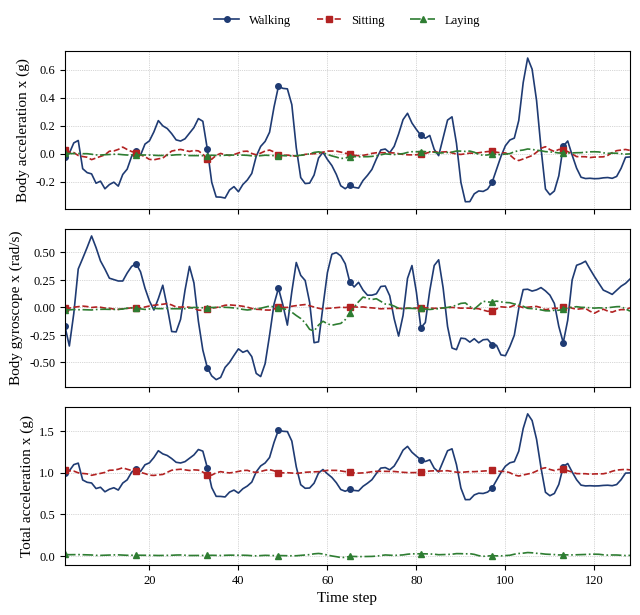

Saved: /content/exp6/figures/plot1_temporal_signals.eps


In [9]:
# CELL 9 - PLOT 1 (sensor signal vs time step): one representative training window for each selected activity,
# three channels stacked vertically. Raw physical units are used. Distinct line styles/markers keep it readable in
# black-and-white print. Saved as figures/plot1_temporal_signals.eps
t = np.arange(1, X_train_raw.shape[1] + 1)                  # time steps 1..128
styles = [('-', 'o'), ('--', 's'), ('-.', '^')]
colors = ['#1f3b73', '#b22222', '#2e7d32']

plot_rng = np.random.default_rng(SEED)
chosen = {c: plot_rng.choice(np.where(y_train == c)[0]) for c in PLOT_CLASSES}

fig, axes = plt.subplots(len(PLOT_CHANNELS), 1, figsize=(6.5, 6.2), sharex=True)
for ax, ch in zip(axes, PLOT_CHANNELS):
    for k, c in enumerate(PLOT_CLASSES):
        ls, mk = styles[k % len(styles)]
        ax.plot(t, X_train_raw[chosen[c], :, ch], linestyle=ls, marker=mk, markevery=16,
                markersize=4, linewidth=1.2, color=colors[k % len(colors)],
                label=CLASS_NAMES[c].title())
    ax.set_ylabel(CHANNEL_LABELS.get(ch, SIGNALS[ch]))
    ax.set_xlim(1, 128)
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.30), ncol=len(PLOT_CLASSES), frameon=False)
axes[-1].set_xlabel('Time step')
fig.tight_layout()
save_fig(fig, 'plot1_temporal_signals')

In [10]:
# P2 CELL 1 - NUMERICAL EXERCISE (NumPy): computes h1, h2, h3 step by step for the Vanilla RNN example,
# printing the pre-activation a_t = Wx*x_t + Wh*h_(t-1) + b and h_t = tanh(a_t).
x_seq = [0.5, 0.7, 0.2]
Wx, Wh, b = 0.5, 0.8, 0.1
h_prev = 0.0

h_numpy = []
for t, xt in enumerate(x_seq, start=1):
    a_t = Wx * xt + Wh * h_prev + b
    h_t = np.tanh(a_t)
    print(f't={t}: a_{t} = {Wx}*{xt} + {Wh}*{h_prev:.6f} + {b} = {a_t:.6f}  ->  h_{t} = tanh(a_{t}) = {h_t:.6f}')
    h_numpy.append(h_t)
    h_prev = h_t

t=1: a_1 = 0.5*0.5 + 0.8*0.000000 + 0.1 = 0.350000  ->  h_1 = tanh(a_1) = 0.336376
t=2: a_2 = 0.5*0.7 + 0.8*0.336376 + 0.1 = 0.719100  ->  h_2 = tanh(a_2) = 0.616352
t=3: a_3 = 0.5*0.2 + 0.8*0.616352 + 0.1 = 0.693081  ->  h_3 = tanh(a_3) = 0.599958


In [11]:
# P2 CELL 2 - VERIFY WITH KERAS + COMPARISON TABLE: runs the same example through a real Keras SimpleRNN layer
# (weights set by hand) and compares hand-calculated, NumPy and Keras values. Replace the 'hand' list with YOUR manual answers.
import pandas as pd
from tensorflow import keras

x_arr = np.array(x_seq, dtype='float32').reshape(1, 3, 1)         # (batch=1, time=3, features=1)
rnn = keras.layers.SimpleRNN(1, activation='tanh', return_sequences=True)
_ = rnn(x_arr)                                                     # builds the layer
rnn.set_weights([np.array([[Wx]], 'float32'),                      # input kernel  Wx
                 np.array([[Wh]], 'float32'),                      # recurrent kernel Wh
                 np.array([b], 'float32')])                        # bias b
h_keras = rnn(x_arr).numpy().flatten()

hand = [0.0000, 0.0000, 0.0000]     # <-- REPLACE with your manually calculated h1, h2, h3 (4 decimals)

table = pd.DataFrame({
    'Step': ['h1', 'h2', 'h3'],
    'Hand': hand,
    'NumPy': np.round(h_numpy, 6),
    'Keras SimpleRNN': np.round(h_keras, 6),
    '|Hand - NumPy|': np.round(np.abs(np.array(hand) - np.array(h_numpy)), 6),
})
print(table.to_string(index=False))

Step  Hand    NumPy  Keras SimpleRNN  |Hand - NumPy|
  h1   0.0 0.336376         0.336376        0.336376
  h2   0.0 0.616352         0.616352        0.616352
  h3   0.0 0.599958         0.599958        0.599958


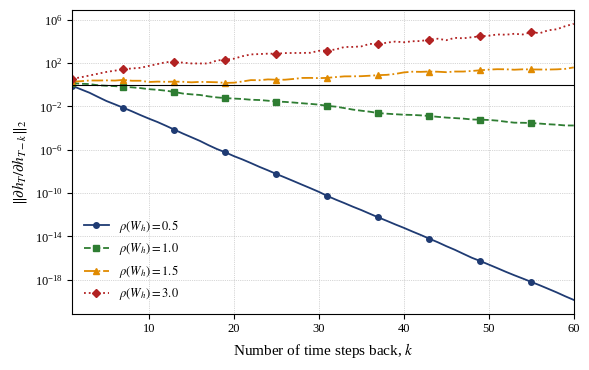

Saved: /content/exp6/figures/plot_bptt_gradient_norms.eps


In [12]:
# P2 CELL 3 - BPTT GRADIENT DEMO (figure for the vanishing/exploding-gradient explanation): builds a 32-unit tanh RNN
# with random recurrent weights scaled to a chosen spectral radius, and plots the norm of dh_T/dh_(T-k) versus k
# on a log axis. Small radius -> gradients vanish; large radius -> gradients explode. Saved as EPS.
def gradient_norms(rho, T=60, H=32, seed=0, x_scale=0.3):
    rng = np.random.default_rng(seed)
    W = rng.normal(size=(H, H))
    W *= rho / np.max(np.abs(np.linalg.eigvals(W)))       # set spectral radius of Wh to rho
    U = rng.normal(size=(H, 3)) * 0.5
    h = np.zeros(H)
    jac = []                                                # jac[t] = dh_t/dh_(t-1) = diag(1 - h_t^2) @ W
    for _ in range(T):
        h = np.tanh(W @ h + U @ (rng.normal(size=3) * x_scale))
        jac.append(np.diag(1 - h**2) @ W)
    P, norms = np.eye(H), []
    for k in range(1, T + 1):
        P = P @ jac[T - k]                                  # dh_T / dh_(T-k)
        norms.append(np.linalg.norm(P, 2))
    return np.array(norms)

k = np.arange(1, 61)
settings = [(0.5, '-', 'o'), (1.0, '--', 's'), (1.5, '-.', '^'), (3.0, ':', 'D')]
colors = ['#1f3b73', '#2e7d32', '#e08a00', '#b22222']

fig, ax = plt.subplots(figsize=(6.0, 3.8))
for (rho, ls, mk), col in zip(settings, colors):
    ax.plot(k, gradient_norms(rho), linestyle=ls, marker=mk, markevery=6, markersize=4,
            linewidth=1.3, color=col, label=rf'$\rho(W_h)={rho}$')
ax.axhline(1.0, color='black', linewidth=0.8)
ax.set_yscale('log')
ax.set_xlabel(r'Number of time steps back, $k$')
ax.set_ylabel(r'$\|\partial h_T / \partial h_{T-k}\|_2$')
ax.set_xlim(1, 60)
ax.legend(frameon=False)
fig.tight_layout()
save_fig(fig, 'plot_bptt_gradient_norms')

In [13]:
# P2 CELL 4 - PARAMETER COUNTS FROM FORMULAS: predicts the trainable parameters of the RNN/LSTM/GRU classifiers
# (recurrent layer + Dense16 + Dense6) before training, so you can check them against model.count_params() in Part 3.
# Note: Keras GRU uses reset_after=True by default, which adds one extra bias vector (2 biases per gate).
F, U, D1, C = 9, 32, 16, 6                 # features, recurrent units, hidden dense units, classes

rec = {
    'RNN':  U * (F + U + 1),               # 1 block: Wx (F*U) + Wh (U*U) + b (U)
    'LSTM': 4 * U * (F + U + 1),           # 4 blocks: forget, input, output gates + candidate
    'GRU':  3 * U * (F + U + 2),           # 3 blocks: update, reset gates + candidate (reset_after=True)
}
head = (U * D1 + D1) + (D1 * C + C)        # Dense(16) + Dense(6); Dropout has no parameters

print(f"{'Model':<6}{'Recurrent':>11}{'Head':>8}{'Total':>9}")
for name, r in rec.items():
    print(f'{name:<6}{r:>11,}{head:>8,}{r + head:>9,}')

Model   Recurrent    Head    Total
RNN         1,344     630    1,974
LSTM        5,376     630    6,006
GRU         4,128     630    4,758


In [14]:
# P3 CELL 1 - SETUP: loads the prepared HAR arrays (Part 1), imports TensorFlow/Keras, and defines the shared
# hyper-parameters used for RNN, LSTM and GRU so the comparison is controlled (manual section 9 configuration).
import json, time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

data = np.load(os.path.join(DATA_DIR, 'har_prepared.npz'), allow_pickle=True)
X_train, y_train = data['X_train'], data['y_train']
X_val,   y_val   = data['X_val'],   data['y_val']
X_test,  y_test  = data['X_test'],  data['y_test']
CLASS_NAMES = list(data['class_names'])

UNITS, DROPOUT, DENSE_UNITS, N_CLASSES = 32, 0.2, 16, 6
LR, BATCH, EPOCHS = 1e-3, 32, 30
MODEL_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

print('Train / Val / Test:', X_train.shape, X_val.shape, X_test.shape)
print('TensorFlow', tf.__version__, '| GPU devices:', tf.config.list_physical_devices('GPU'))

Train / Val / Test: (2100, 128, 9) (450, 128, 9) (450, 128, 9)
TensorFlow 2.20.0 | GPU devices: []


In [15]:
# P3 CELL 2 - MODEL BUILDER: one function builds the RNN, LSTM or GRU classifier. Only the recurrent layer changes;
# input, Dropout(0.2), Dense(16, ReLU), Dense(6, softmax), Adam(1e-3) and the loss are identical (sections 9 and 12).
# Also prints each summary and checks the parameter counts against the formulas from Part 2.
def build_model(kind, T=128, F=9):
    rec_layer = {'RNN': layers.SimpleRNN, 'LSTM': layers.LSTM, 'GRU': layers.GRU}[kind]
    model = keras.Sequential([
        keras.Input(shape=(T, F)),
        rec_layer(UNITS),
        layers.Dropout(DROPOUT),
        layers.Dense(DENSE_UNITS, activation='relu'),
        layers.Dense(N_CLASSES, activation='softmax'),
    ], name=kind.lower())
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=LR),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

expected = {'RNN': 1974, 'LSTM': 6006, 'GRU': 4758}
for kind in ['RNN', 'LSTM', 'GRU']:
    m = build_model(kind)
    m.summary()
    print(f'{kind}: trainable parameters = {m.count_params():,}  (expected {expected[kind]:,})\n')

Model: "rnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)

GRU: trainable parameters = 4,758  (expected 4,758)



In [16]:
# P3 CELL 3 - TRAIN ALL THREE MODELS: same seed, same data, 30 epochs, batch 32. Records the wall-clock training time
# of each model and saves the trained models + histories to disk for Part 4 (evaluation on the test set).
# A short warm-up run first, so start-up cost is not charged to whichever model happens to train first.
histories, train_time = {}, {}

for kind in ['RNN', 'LSTM', 'GRU']:
    w = build_model(kind)
    w.fit(X_train[:64], y_train[:64], epochs=1, batch_size=BATCH, verbose=0)
    del w

for kind in ['RNN', 'LSTM', 'GRU']:
    keras.utils.set_random_seed(SEED)
    model = build_model(kind)
    print(f'\n===== Training {kind} =====')
    t0 = time.perf_counter()
    hist = model.fit(X_train, y_train,
                     validation_data=(X_val, y_val),
                     epochs=EPOCHS, batch_size=BATCH, shuffle=True, verbose=2)
    train_time[kind] = time.perf_counter() - t0
    histories[kind] = {k: [float(v) for v in vals] for k, vals in hist.history.items()}
    model.save(os.path.join(MODEL_DIR, f'{kind.lower()}_T128.keras'))
    print(f'{kind}: training time = {train_time[kind]:.1f} s')

with open(os.path.join(MODEL_DIR, 'histories_T128.json'), 'w') as f:
    json.dump({'histories': histories, 'train_time': train_time}, f)
print('\nSaved models and histories to', MODEL_DIR)


===== Training RNN =====
Epoch 1/30
66/66 - 4s - 66ms/step - accuracy: 0.3829 - loss: 1.6328 - val_accuracy: 0.4000 - val_loss: 1.4711
Epoch 2/30
66/66 - 1s - 20ms/step - accuracy: 0.4610 - loss: 1.3226 - val_accuracy: 0.4822 - val_loss: 1.2057
Epoch 3/30
66/66 - 3s - 38ms/step - accuracy: 0.5452 - loss: 1.1124 - val_accuracy: 0.5822 - val_loss: 1.0410
Epoch 4/30
66/66 - 1s - 20ms/step - accuracy: 0.5905 - loss: 0.9703 - val_accuracy: 0.6156 - val_loss: 0.9105
Epoch 5/30
66/66 - 1s - 20ms/step - accuracy: 0.5990 - loss: 0.8874 - val_accuracy: 0.6222 - val_loss: 0.8389
Epoch 6/30
66/66 - 1s - 20ms/step - accuracy: 0.6124 - loss: 0.8370 - val_accuracy: 0.6533 - val_loss: 0.7717
Epoch 7/30
66/66 - 1s - 20ms/step - accuracy: 0.6310 - loss: 0.7745 - val_accuracy: 0.6689 - val_loss: 0.7198
Epoch 8/30
66/66 - 2s - 26ms/step - accuracy: 0.6433 - loss: 0.7275 - val_accuracy: 0.6689 - val_loss: 0.7013
Epoch 9/30
66/66 - 2s - 35ms/step - accuracy: 0.6476 - loss: 0.7125 - val_accuracy: 0.6689 - v

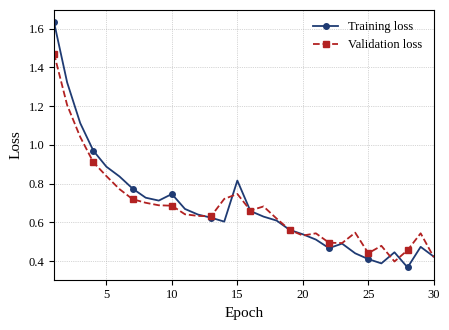

Saved: /content/exp6/figures/plot2_loss_rnn.eps


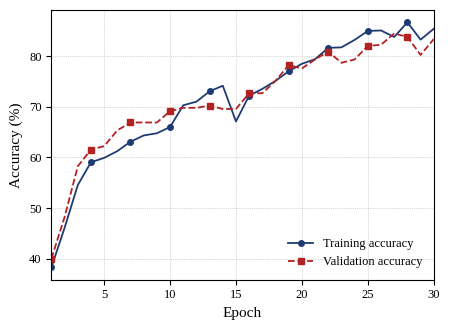

Saved: /content/exp6/figures/plot3_acc_rnn.eps


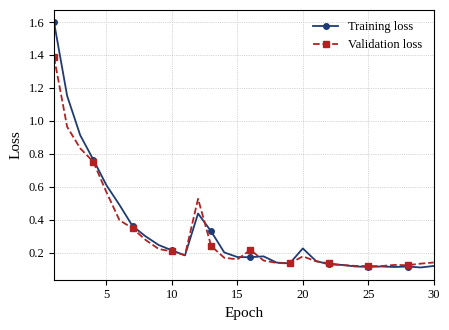

Saved: /content/exp6/figures/plot2_loss_lstm.eps


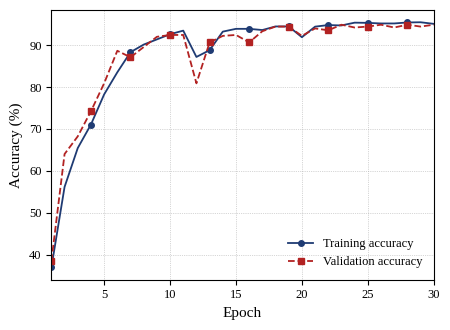

Saved: /content/exp6/figures/plot3_acc_lstm.eps


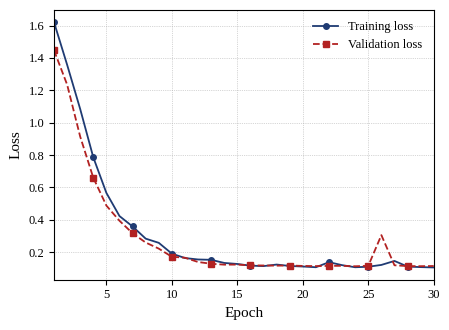

Saved: /content/exp6/figures/plot2_loss_gru.eps


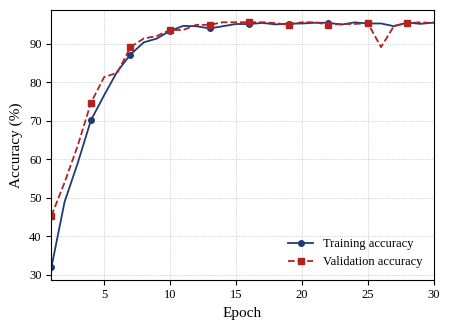

Saved: /content/exp6/figures/plot3_acc_gru.eps


In [17]:
# P3 CELL 4 - PLOTS 2 AND 3 (per model): training vs validation loss (Plot 2) and training vs validation accuracy in %
# (Plot 3) for RNN, LSTM and GRU. Six separate EPS figures, e.g. plot2_loss_rnn.eps, plot3_acc_gru.eps.
c_tr, c_va = '#1f3b73', '#b22222'
for kind in ['RNN', 'LSTM', 'GRU']:
    h = histories[kind]
    ep = np.arange(1, len(h['loss']) + 1)

    fig, ax = plt.subplots(figsize=(4.6, 3.4))
    ax.plot(ep, h['loss'], '-o', color=c_tr, markevery=3, markersize=4, linewidth=1.3, label='Training loss')
    ax.plot(ep, h['val_loss'], '--s', color=c_va, markevery=3, markersize=4, linewidth=1.3, label='Validation loss')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_xlim(1, len(ep))
    ax.legend(frameon=False)
    fig.tight_layout()
    save_fig(fig, f'plot2_loss_{kind.lower()}')

    fig, ax = plt.subplots(figsize=(4.6, 3.4))
    ax.plot(ep, np.array(h['accuracy']) * 100, '-o', color=c_tr, markevery=3, markersize=4, linewidth=1.3, label='Training accuracy')
    ax.plot(ep, np.array(h['val_accuracy']) * 100, '--s', color=c_va, markevery=3, markersize=4, linewidth=1.3, label='Validation accuracy')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)'); ax.set_xlim(1, len(ep))
    ax.legend(frameon=False, loc='lower right')
    fig.tight_layout()
    save_fig(fig, f'plot3_acc_{kind.lower()}')

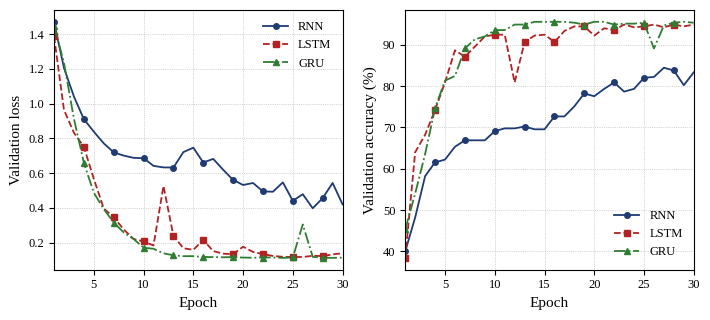

Saved: /content/exp6/figures/plot_val_curves_all_models.eps


In [18]:
# P3 CELL 5 - EXTRA FIGURE (optional, helps the convergence discussion): validation loss and validation accuracy of
# the three models on the same axes, so their convergence speed and stability can be compared directly.
mc = {'RNN': ('#1f3b73', '-', 'o'), 'LSTM': ('#b22222', '--', 's'), 'GRU': ('#2e7d32', '-.', '^')}
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.3))
for kind, (col, ls, mk) in mc.items():
    h = histories[kind]; ep = np.arange(1, len(h['loss']) + 1)
    axes[0].plot(ep, h['val_loss'], linestyle=ls, marker=mk, markevery=3, markersize=4, linewidth=1.3, color=col, label=kind)
    axes[1].plot(ep, np.array(h['val_accuracy']) * 100, linestyle=ls, marker=mk, markevery=3, markersize=4, linewidth=1.3, color=col, label=kind)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation accuracy (%)')
for a in axes:
    a.set_xlim(1, len(ep)); a.legend(frameon=False)
fig.tight_layout()
save_fig(fig, 'plot_val_curves_all_models')

In [19]:
# P3 CELL 6 - CONVERGENCE SUMMARY TABLE: final/best accuracy, generalisation gap, epoch of best validation
# performance, stability over the last 10 epochs, and training time. Use these numbers to back your
# convergence / overfitting / underfitting inferences.
import pandas as pd
rows = []
for kind in ['RNN', 'LSTM', 'GRU']:
    h = histories[kind]
    ta, va = np.array(h['accuracy']) * 100, np.array(h['val_accuracy']) * 100
    tl, vl = np.array(h['loss']), np.array(h['val_loss'])
    first90 = int(np.argmax(va >= 90)) + 1 if (va >= 90).any() else None
    rows.append({
        'Model': kind,
        'Final train acc (%)': ta[-1], 'Final val acc (%)': va[-1], 'Gap train-val (%)': ta[-1] - va[-1],
        'Best val acc (%)': va.max(), 'Best val acc epoch': int(va.argmax()) + 1,
        'Final train loss': tl[-1], 'Final val loss': vl[-1],
        'Min val loss': vl.min(), 'Min val loss epoch': int(vl.argmin()) + 1,
        'Val acc std, last 10 ep': va[-10:].std(),
        'First epoch val acc >= 90%': first90,
        'Train time (s)': train_time[kind],
    })
summary = pd.DataFrame(rows).set_index('Model').round(3)
print(summary.T.to_string())

Model                          RNN    LSTM      GRU
Final train acc (%)         85.381  95.095   95.476
Final val acc (%)           83.333  94.889   95.333
Gap train-val (%)            2.048   0.206    0.143
Best val acc (%)            84.444  94.889   95.556
Best val acc epoch          27.000  23.000   14.000
Final train loss             0.423   0.119    0.105
Final val loss               0.421   0.140    0.114
Min val loss                 0.398   0.118    0.112
Min val loss epoch          27.000  25.000   24.000
Val acc std, last 10 ep      1.933   0.433    1.849
First epoch val acc >= 90%     NaN   9.000    8.000
Train time (s)              55.159  93.900  134.840


In [20]:
# P4 CELL 1 - EVALUATE ON THE TEST SET: loads the three trained models, predicts on the untouched test set, and computes
# accuracy, macro precision/recall/F1, parameter count and the confusion matrix for each model (section 14).
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

KINDS = ['RNN', 'LSTM', 'GRU']
models = {k: keras.models.load_model(os.path.join(MODEL_DIR, f'{k.lower()}_T128.keras')) for k in KINDS}

if 'train_time' not in globals():                       # only needed if the runtime was restarted
    with open(os.path.join(MODEL_DIR, 'histories_T128.json')) as f:
        train_time = json.load(f)['train_time']

results, preds, cms = {}, {}, {}
for k in KINDS:
    probs = models[k].predict(X_test, batch_size=64, verbose=0)
    y_pred = probs.argmax(axis=1)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
    results[k] = {
        'Accuracy (%)': accuracy_score(y_test, y_pred) * 100,
        'Macro Precision (%)': p * 100,
        'Macro Recall (%)': r * 100,
        'Macro F1 (%)': f1 * 100,
        'Parameters': int(models[k].count_params()),
        'Training Time (s)': float(train_time[k]),
    }
    preds[k] = y_pred
    cms[k] = confusion_matrix(y_test, y_pred, labels=range(len(CLASS_NAMES)))
    print(f'{k}: evaluated on {len(y_test)} test windows')

RNN: evaluated on 450 test windows
LSTM: evaluated on 450 test windows


GRU: evaluated on 450 test windows


In [21]:
# P4 CELL 2 - RESULTS TABLE (section 14): prints the metric table in the manual's layout (rows = metrics,
# columns = RNN / LSTM / GRU) and saves the numeric results to CSV for the consolidated table in Part 8.
fmt = {'Accuracy (%)': '{:.2f}', 'Macro Precision (%)': '{:.2f}', 'Macro Recall (%)': '{:.2f}',
       'Macro F1 (%)': '{:.2f}', 'Parameters': '{:,}', 'Training Time (s)': '{:.1f}'}
table14 = pd.DataFrame({k: {m: fmt[m].format(results[k][m]) for m in fmt} for k in KINDS})
table14.index.name = 'Metric'
print(table14.to_string())

pd.DataFrame(results).T.to_csv(os.path.join(DATA_DIR, 'results_T128.csv'))
print('\nSaved numeric results to', os.path.join(DATA_DIR, 'results_T128.csv'))

                       RNN   LSTM    GRU
Metric                                  
Accuracy (%)         81.11  94.00  92.00
Macro Precision (%)  81.90  94.06  92.33
Macro Recall (%)     81.11  94.00  92.00
Macro F1 (%)         80.99  94.01  91.94
Parameters           1,974  6,006  4,758
Training Time (s)     55.2   93.9  134.8

Saved numeric results to /content/exp6/data/results_T128.csv


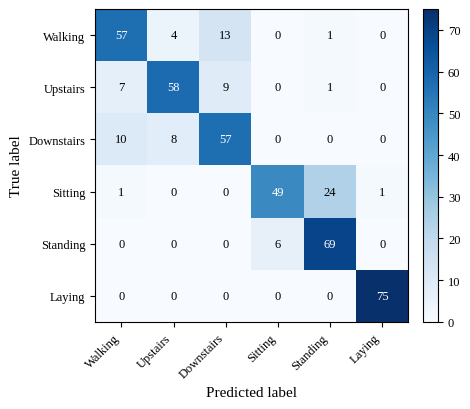

Saved: /content/exp6/figures/plot4_confusion_rnn.eps


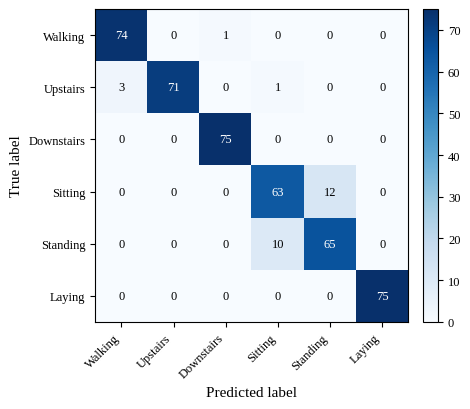

Saved: /content/exp6/figures/plot4_confusion_lstm.eps


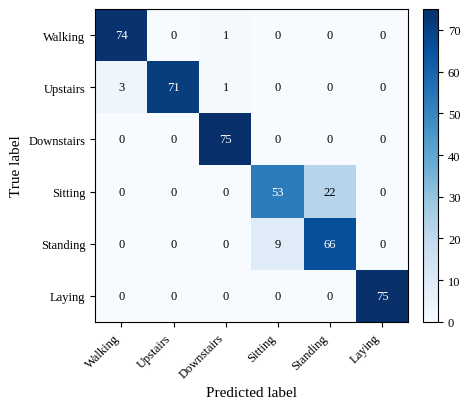

Saved: /content/exp6/figures/plot4_confusion_gru.eps


In [22]:
# P4 CELL 3 - PLOT 4 (confusion matrices): one figure per model with raw counts in each cell.
# Saved as plot4_confusion_rnn.eps, plot4_confusion_lstm.eps, plot4_confusion_gru.eps
short = ['Walking', 'Upstairs', 'Downstairs', 'Sitting', 'Standing', 'Laying']
for k in KINDS:
    cm = cms[k]
    fig, ax = plt.subplots(figsize=(4.8, 4.2))
    im = ax.imshow(cm, cmap='Blues', vmin=0)
    ax.set_xticks(range(6)); ax.set_xticklabels(short, rotation=45, ha='right')
    ax.set_yticks(range(6)); ax.set_yticklabels(short)
    ax.grid(False)
    thresh = cm.max() / 2
    for i in range(6):
        for j in range(6):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=9,
                    color='white' if cm[i, j] > thresh else 'black')
    ax.set_xlabel('Predicted label'); ax.set_ylabel('True label')
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.grid(False)
    fig.tight_layout()
    save_fig(fig, f'plot4_confusion_{k.lower()}')

In [23]:
# P4 CELL 4 - CONFUSION-MATRIX ANALYSIS (section 15): for each model prints the best and worst recognised activity,
# the activity with the most misclassified windows, and the most-confused pairs, then checks which confusions are
# shared by all three models. Use this printout to write the inference from YOUR matrices.
recall_tbl = pd.DataFrame({k: cms[k].diagonal() / cms[k].sum(axis=1) * 100 for k in KINDS},
                          index=CLASS_NAMES).round(1)
print('Per-class recall (%):')
print(recall_tbl.to_string())

top_pairs = {}
for k in KINDS:
    cm = cms[k]
    errs = cm.sum(axis=1) - cm.diagonal()
    print(f'\n===== {k} =====')
    print(f'Highest recognition rate : {recall_tbl[k].idxmax()} ({recall_tbl[k].max():.1f}%)')
    print(f'Lowest recognition rate  : {recall_tbl[k].idxmin()} ({recall_tbl[k].min():.1f}%)')
    print(f'Most misclassified windows: {CLASS_NAMES[errs.argmax()]} ({errs.max()} of {cm.sum(axis=1)[errs.argmax()]})')
    pairs = []
    for i in range(6):
        for j in range(i + 1, 6):
            total = cm[i, j] + cm[j, i]
            if total > 0:
                pairs.append((total, i, j))
    pairs.sort(reverse=True)
    top_pairs[k] = [(i, j) for _, i, j in pairs[:3]]
    print('Most confused pairs (count both directions):')
    for total, i, j in pairs[:3]:
        print(f'  {CLASS_NAMES[i]} <-> {CLASS_NAMES[j]}: {total}  '
              f'({CLASS_NAMES[i]}->{CLASS_NAMES[j]}: {cm[i, j]}, {CLASS_NAMES[j]}->{CLASS_NAMES[i]}: {cm[j, i]})')
    print(classification_report(y_test, preds[k], target_names=CLASS_NAMES, digits=3, zero_division=0))

common = set(top_pairs['RNN']) & set(top_pairs['LSTM']) & set(top_pairs['GRU'])
print('Pairs in the top-3 confusions of ALL three models:',
      [f'{CLASS_NAMES[i]} <-> {CLASS_NAMES[j]}' for i, j in common] or 'none')

Per-class recall (%):
                      RNN   LSTM    GRU
WALKING              76.0   98.7   98.7
WALKING UPSTAIRS     77.3   94.7   94.7
WALKING DOWNSTAIRS   76.0  100.0  100.0
SITTING              65.3   84.0   70.7
STANDING             92.0   86.7   88.0
LAYING              100.0  100.0  100.0

===== RNN =====
Highest recognition rate : LAYING (100.0%)
Lowest recognition rate  : SITTING (65.3%)
Most misclassified windows: SITTING (26 of 75)
Most confused pairs (count both directions):
  SITTING <-> STANDING: 30  (SITTING->STANDING: 24, STANDING->SITTING: 6)
  WALKING <-> WALKING DOWNSTAIRS: 23  (WALKING->WALKING DOWNSTAIRS: 13, WALKING DOWNSTAIRS->WALKING: 10)
  WALKING UPSTAIRS <-> WALKING DOWNSTAIRS: 17  (WALKING UPSTAIRS->WALKING DOWNSTAIRS: 9, WALKING DOWNSTAIRS->WALKING UPSTAIRS: 8)
                    precision    recall  f1-score   support

           WALKING      0.760     0.760     0.760        75
  WALKING UPSTAIRS      0.829     0.773     0.800        75
WALKING DOWNS

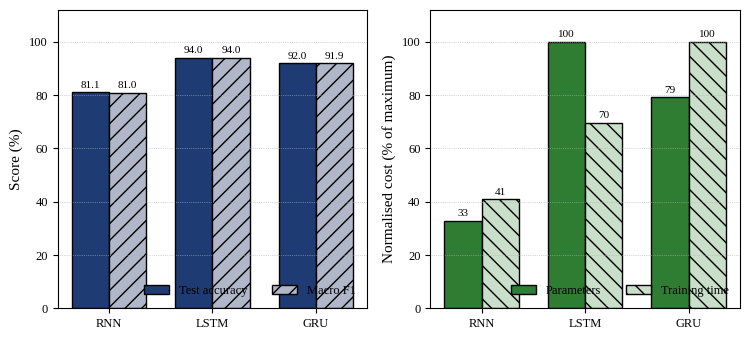

Saved: /content/exp6/figures/plot5_model_comparison.eps


In [24]:
# P4 CELL 5 - PLOT 5 (model performance comparison): left panel = test accuracy and macro F1 (%); right panel =
# computational cost normalised to the largest model (parameters and training time, % of maximum).
# Hatching keeps the bars distinguishable in black-and-white print. Saved as plot5_model_comparison.eps
def add_labels(ax, bars, fmt='{:.1f}'):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1, fmt.format(b.get_height()),
                ha='center', va='bottom', fontsize=8)

x, w = np.arange(3), 0.36
acc = [results[k]['Accuracy (%)'] for k in KINDS]
f1 = [results[k]['Macro F1 (%)'] for k in KINDS]
params = np.array([results[k]['Parameters'] for k in KINDS], dtype=float)
times = np.array([results[k]['Training Time (s)'] for k in KINDS], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.5))

b1 = axes[0].bar(x - w / 2, acc, w, color='#1f3b73', edgecolor='black', label='Test accuracy')
b2 = axes[0].bar(x + w / 2, f1, w, color='#b0b7c9', edgecolor='black', hatch='//', label='Macro F1')
add_labels(axes[0], b1); add_labels(axes[0], b2)
axes[0].set_xticks(x); axes[0].set_xticklabels(KINDS)
axes[0].set_ylabel('Score (%)'); axes[0].set_ylim(0, 112)
axes[0].legend(frameon=False, loc='lower right', ncol=2)

c1 = axes[1].bar(x - w / 2, params / params.max() * 100, w, color='#2e7d32', edgecolor='black', label='Parameters')
c2 = axes[1].bar(x + w / 2, times / times.max() * 100, w, color='#c9dfc9', edgecolor='black', hatch='\\\\', label='Training time')
add_labels(axes[1], c1, '{:.0f}'); add_labels(axes[1], c2, '{:.0f}')
axes[1].set_xticks(x); axes[1].set_xticklabels(KINDS)
axes[1].set_ylabel('Normalised cost (% of maximum)'); axes[1].set_ylim(0, 112)
axes[1].legend(frameon=False, loc='lower right', ncol=2)

for a in axes:
    a.grid(axis='x', visible=False)
fig.tight_layout()
save_fig(fig, 'plot5_model_comparison')

In [25]:
# P4 CELL 6 - RNN vs LSTM vs GRU COMPARISON TABLE (section 16): fills the manual's property table (gates and states,
# then measured parameters, training time and test F1) and prints a LaTeX version you can paste into Overleaf.
yn = lambda a, b, c: [a, b, c]
rows = {
    'Hidden state':  yn('Yes', 'Yes', 'Yes'),
    'Cell state':    yn('No', 'Yes', 'No'),
    'Forget gate':   yn('No', 'Yes', 'No'),
    'Input gate':    yn('No', 'Yes', 'No'),
    'Output gate':   yn('No', 'Yes', 'No'),
    'Update gate':   yn('No', 'No', 'Yes'),
    'Reset gate':    yn('No', 'No', 'Yes'),
    'Parameters':    [f"{results[k]['Parameters']:,}" for k in KINDS],
    'Training time (s)': [f"{results[k]['Training Time (s)']:.1f}" for k in KINDS],
    'Test F1-score (%)': [f"{results[k]['Macro F1 (%)']:.2f}" for k in KINDS],
}
comp = pd.DataFrame(rows, index=KINDS).T
comp.index.name = 'Property'
print(comp.to_string())
try:
    print('\nLaTeX version:\n', comp.to_latex())
except Exception as e:
    print('to_latex unavailable:', e)

                     RNN   LSTM    GRU
Property                              
Hidden state         Yes    Yes    Yes
Cell state            No    Yes     No
Forget gate           No    Yes     No
Input gate            No    Yes     No
Output gate           No    Yes     No
Update gate           No     No    Yes
Reset gate            No     No    Yes
Parameters         1,974  6,006  4,758
Training time (s)   55.2   93.9  134.8
Test F1-score (%)  80.99  94.01  91.94

LaTeX version:
 \begin{tabular}{llll}
\toprule
 & RNN & LSTM & GRU \\
Property &  &  &  \\
\midrule
Hidden state & Yes & Yes & Yes \\
Cell state & No & Yes & No \\
Forget gate & No & Yes & No \\
Input gate & No & Yes & No \\
Output gate & No & Yes & No \\
Update gate & No & No & Yes \\
Reset gate & No & No & Yes \\
Parameters & 1,974 & 6,006 & 4,758 \\
Training time (s) & 55.2 & 93.9 & 134.8 \\
Test F1-score (%) & 80.99 & 94.01 & 91.94 \\
\bottomrule
\end{tabular}



In [26]:
# P5 CELL 1 - EXPERIMENT FUNCTION: trains and evaluates one model (RNN/LSTM/GRU) on the FIRST T time steps of every
# window, with exactly the same seed, hyper-parameters and split as before. Returns test accuracy, macro F1,
# parameter count and training time. (Section 17: consistent truncation for all models and lengths.)
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import pandas as pd, json, time

KINDS = ['RNN', 'LSTM', 'GRU']
SEQ_LENGTHS = [32, 64, 128]

def run_experiment(kind, T):
    Xtr, Xva, Xte = X_train[:, :T, :], X_val[:, :T, :], X_test[:, :T, :]
    w = build_model(kind, T=T)                                    # warm-up: excludes graph start-up from timing
    w.fit(Xtr[:64], y_train[:64], epochs=1, batch_size=BATCH, verbose=0)
    del w
    keras.utils.set_random_seed(SEED)
    model = build_model(kind, T=T)
    t0 = time.perf_counter()
    model.fit(Xtr, y_train, validation_data=(Xva, y_val),
              epochs=EPOCHS, batch_size=BATCH, shuffle=True, verbose=0)
    tt = time.perf_counter() - t0
    y_pred = model.predict(Xte, batch_size=64, verbose=0).argmax(axis=1)
    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro', zero_division=0)
    model.save(os.path.join(MODEL_DIR, f'{kind.lower()}_T{T}.keras'))
    return {'Accuracy (%)': accuracy_score(y_test, y_pred) * 100, 'Macro F1 (%)': f1 * 100,
            'Parameters': int(model.count_params()), 'Training Time (s)': tt}

In [27]:
# P5 CELL 2 - RUN THE STUDY: trains the T = 32 and T = 64 models for all three architectures (T = 128 is reused from
# Part 4), prints each result as it finishes, and saves everything to seqlen_results.csv for the report tables.
if 'results' not in globals():                                    # only if the runtime was restarted after Part 4
    results = pd.read_csv(os.path.join(DATA_DIR, 'results_T128.csv'), index_col=0).to_dict('index')

rows = []
for T in SEQ_LENGTHS:
    for k in KINDS:
        if T == 128:                                              # already trained and evaluated in Parts 3-4
            res = {m: results[k][m] for m in ['Accuracy (%)', 'Macro F1 (%)', 'Parameters', 'Training Time (s)']}
        else:
            res = run_experiment(k, T)
        rows.append({'Model': k, 'T': T, **res})
        print(f"T={T:<4}{k:<5} acc={res['Accuracy (%)']:.2f}%  macro-F1={res['Macro F1 (%)']:.2f}%  "
              f"time={res['Training Time (s)']:.1f}s")

df_len = pd.DataFrame(rows)
df_len.to_csv(os.path.join(DATA_DIR, 'seqlen_results.csv'), index=False)
print('\nSaved', os.path.join(DATA_DIR, 'seqlen_results.csv'))

T=32  RNN   acc=77.56%  macro-F1=77.57%  time=20.0s
T=32  LSTM  acc=91.33%  macro-F1=91.33%  time=34.0s
T=32  GRU   acc=90.00%  macro-F1=89.88%  time=40.3s
T=64  RNN   acc=79.11%  macro-F1=78.88%  time=30.0s
T=64  LSTM  acc=94.00%  macro-F1=94.00%  time=60.2s
T=64  GRU   acc=92.44%  macro-F1=92.35%  time=70.9s
T=128 RNN   acc=81.11%  macro-F1=80.99%  time=55.2s
T=128 LSTM  acc=94.00%  macro-F1=94.01%  time=93.9s
T=128 GRU   acc=92.00%  macro-F1=91.94%  time=134.8s

Saved /content/exp6/data/seqlen_results.csv


In [28]:
# P5 CELL 3 - TABLES: prints the sequence-length table from the manual (test macro F1 for RNN/LSTM/GRU at each T),
# plus test accuracy and training time versus T (the latter answers additional exercise 5 on computational cost).
f1_tbl = df_len.pivot(index='T', columns='Model', values='Macro F1 (%)')[KINDS].round(2)
f1_tbl.columns = [f'{k} F1 (%)' for k in KINDS]
f1_tbl.index.name = 'Sequence Length'
print('Test macro F1 versus sequence length:')
print(f1_tbl.to_string())

acc_tbl = df_len.pivot(index='T', columns='Model', values='Accuracy (%)')[KINDS].round(2)
acc_tbl.index.name = 'Sequence Length'
print('\nTest accuracy (%):')
print(acc_tbl.to_string())

time_tbl = df_len.pivot(index='T', columns='Model', values='Training Time (s)')[KINDS].round(1)
time_tbl.index.name = 'Sequence Length'
print('\nTraining time (s):')
print(time_tbl.to_string())

Test macro F1 versus sequence length:
                 RNN F1 (%)  LSTM F1 (%)  GRU F1 (%)
Sequence Length                                     
32                    77.57        91.33       89.88
64                    78.88        94.00       92.35
128                   80.99        94.01       91.94

Test accuracy (%):
Model              RNN   LSTM    GRU
Sequence Length                     
32               77.56  91.33  90.00
64               79.11  94.00  92.44
128              81.11  94.00  92.00

Training time (s):
Model             RNN  LSTM    GRU
Sequence Length                   
32               20.0  34.0   40.3
64               30.0  60.2   70.9
128              55.2  93.9  134.8


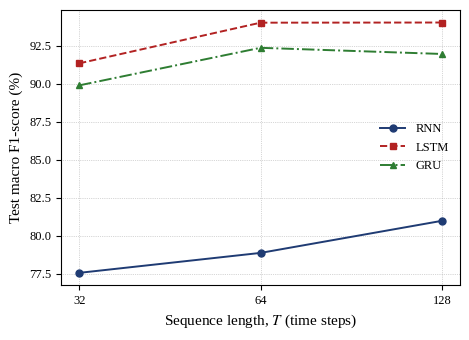

Saved: /content/exp6/figures/plot6_seqlen_vs_f1.eps


In [29]:
# P5 CELL 4 - PLOT 6 (sequence length vs. test F1-score): one line per model, x-axis on a log-2 scale so that
# 32, 64 and 128 are evenly spaced. Saved as plot6_seqlen_vs_f1.eps
styles = {'RNN': ('#1f3b73', '-', 'o'), 'LSTM': ('#b22222', '--', 's'), 'GRU': ('#2e7d32', '-.', '^')}
fig, ax = plt.subplots(figsize=(4.8, 3.5))
for k, (col, ls, mk) in styles.items():
    d = df_len[df_len['Model'] == k].sort_values('T')
    ax.plot(d['T'], d['Macro F1 (%)'], linestyle=ls, marker=mk, markersize=5, linewidth=1.4, color=col, label=k)
ax.set_xscale('log', base=2)
ax.set_xticks(SEQ_LENGTHS); ax.set_xticklabels([str(t) for t in SEQ_LENGTHS])
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.set_xlabel('Sequence length, $T$ (time steps)')
ax.set_ylabel('Test macro F1-score (%)')
ax.legend(frameon=False)
fig.tight_layout()
save_fig(fig, 'plot6_seqlen_vs_f1')

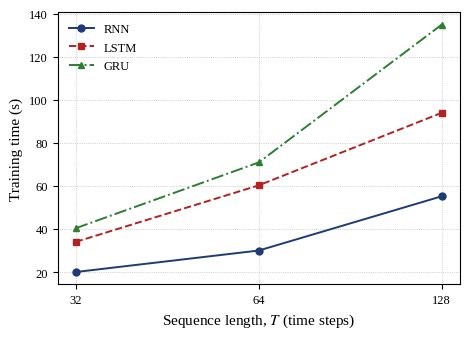

Saved: /content/exp6/figures/plot_seqlen_vs_time.eps


In [30]:
# P5 CELL 5 - OPTIONAL EXTRA FIGURE: training time versus sequence length for the three models
# (additional exercise 5). Saved as plot_seqlen_vs_time.eps
fig, ax = plt.subplots(figsize=(4.8, 3.5))
for k, (col, ls, mk) in styles.items():
    d = df_len[df_len['Model'] == k].sort_values('T')
    ax.plot(d['T'], d['Training Time (s)'], linestyle=ls, marker=mk, markersize=5, linewidth=1.4, color=col, label=k)
ax.set_xscale('log', base=2)
ax.set_xticks(SEQ_LENGTHS); ax.set_xticklabels([str(t) for t in SEQ_LENGTHS])
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.set_xlabel('Sequence length, $T$ (time steps)')
ax.set_ylabel('Training time (s)')
ax.legend(frameon=False)
fig.tight_layout()
save_fig(fig, 'plot_seqlen_vs_time')

In [31]:
# P6 CELL 1 - SETUP: imports, the 4 UCF101 classes, 10 frames per video at 224x224, folder paths, the group-based
# train/val/test rule, and the recurrent-head hyper-parameters (32 units, dropout 0.2, Adam 1e-3).
import re, glob, subprocess, time, json
import cv2
from tqdm.auto import tqdm
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

CLASSES = ['Basketball', 'Biking', 'TennisSwing', 'WalkingWithDog']   # 3-5 UCF101 classes
N_FRAMES, IMG = 10, 224
UCF_URL = 'https://www.crcv.ucf.edu/data/UCF101/UCF101.rar'
VIDEO_DIR = os.path.join(BASE_DIR, 'ucf101')
MODEL_DIR = os.path.join(BASE_DIR, 'models')
FEAT_PATH = os.path.join(DATA_DIR, 'ucf101_features.npz')
for d in (VIDEO_DIR, MODEL_DIR):
    os.makedirs(d, exist_ok=True)

TEST_GROUPS, VAL_GROUPS = range(1, 8), range(8, 12)                  # groups 12-25 -> training
V_UNITS, V_DROPOUT, V_LR, V_BATCH, V_EPOCHS = 32, 0.2, 1e-3, 16, 30
print('TensorFlow', tf.__version__, '| GPU devices:', tf.config.list_physical_devices('GPU'))

TensorFlow 2.20.0 | GPU devices: []


In [32]:
# P6 CELL 2 - GET THE VIDEOS: downloads UCF101.rar (~6.5 GB) and extracts ONLY the chosen classes, then prints how
# many videos each class has. Skips everything that is already on disk.
# If the UCF server is slow/blocked, download the rar elsewhere and upload it to VIDEO_DIR, or upload just the class folders.
rar_path = os.path.join(VIDEO_DIR, 'UCF101.rar')
n_videos = lambda c: len(glob.glob(os.path.join(VIDEO_DIR, 'UCF-101', c, '*.avi')))
todo = [c for c in CLASSES if n_videos(c) == 0]

if todo:
    if not os.path.exists(rar_path):
        print('Downloading UCF101.rar (about 6.5 GB, can take several minutes) ...')
        get_ipython().system(f'wget -c -q --show-progress --no-check-certificate -P "{VIDEO_DIR}" {UCF_URL}')
    get_ipython().system('apt-get -qq install -y unrar > /dev/null')
    for c in todo:
        subprocess.run(['unrar', 'x', '-y', '-inul', rar_path, f'UCF-101/{c}/*', VIDEO_DIR + '/'])

for c in CLASSES:
    n = n_videos(c)
    print(f'{c:<16}{n:>4} videos')
    if n == 0:
        print('   -> not found. Check the class name (list all with: unrar lb UCF101.rar | cut -d/ -f2 | sort -u)')

UCF101.rar          100%[===================>]   6.46G   142MB/s    in 66s     
Basketball       134 videos
Biking           134 videos
TennisSwing      166 videos
WalkingWithDog   123 videos


In [33]:
# P6 CELL 3 - SPLIT BY GROUP: assigns every clip to train/val/test using its UCF101 group number (g01-g25) so that
# clips cut from the same source video never appear in different splits. Prints the per-class counts.
def get_group(path):
    return int(re.search(r'_g(\d+)_c', os.path.basename(path)).group(1))

splits = {'train': [], 'val': [], 'test': []}
for ci, c in enumerate(CLASSES):
    for p in sorted(glob.glob(os.path.join(VIDEO_DIR, 'UCF-101', c, '*.avi'))):
        g = get_group(p)
        key = 'test' if g in TEST_GROUPS else 'val' if g in VAL_GROUPS else 'train'
        splits[key].append((p, ci))

print(f"{'Class':<16}{'Train':>7}{'Val':>6}{'Test':>6}")
for ci, c in enumerate(CLASSES):
    print(f"{c:<16}" + ''.join(f"{sum(1 for _, l in splits[s] if l == ci):>{w}}" for s, w in [('train', 7), ('val', 6), ('test', 6)]))
print('Total videos:', {s: len(v) for s, v in splits.items()})

Class             Train   Val  Test
Basketball           80    19    35
Biking               74    22    38
TennisSwing          90    27    49
WalkingWithDog       66    21    36
Total videos: {'train': 310, 'val': 89, 'test': 158}


In [34]:
# P6 CELL 4 - FRAME SAMPLING + CNN FEATURE EXTRACTION (sections 19-20): samples 10 frames uniformly from each video,
# resizes to 224x224x3, passes them through a FROZEN pretrained MobileNetV2 (no classification head, global average
# pooling) and stacks the results into (N, 10, D). Features are cached, so this only runs once.
# Prints the required observation: the CNN feature dimension D and the tensor shape fed to the recurrent network.
def read_frames(path, n=N_FRAMES, size=IMG):
    """Return n frames sampled uniformly over the video as (n, size, size, 3) RGB uint8."""
    cap = cv2.VideoCapture(path)
    frames = []
    while True:
        ok, f = cap.read()
        if not ok:
            break
        frames.append(f)
    cap.release()
    if not frames:
        return None
    idx = np.linspace(0, len(frames) - 1, n).round().astype(int)
    return np.stack([cv2.cvtColor(cv2.resize(frames[i], (size, size)), cv2.COLOR_BGR2RGB) for i in idx]).astype(np.uint8)

cnn = keras.applications.MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(IMG, IMG, 3))
cnn.trainable = False                                            # frozen feature extractor
D = int(cnn.output_shape[-1])
print('CNN feature dimension D =', D, '| frozen CNN parameters =', f'{cnn.count_params():,}')

def extract_split(paths, chunk=16):
    feats, kept = [], []
    for s in tqdm(range(0, len(paths), chunk)):
        fr_list, idx_list = [], []
        for j, p in enumerate(paths[s:s + chunk]):
            fr = read_frames(p)
            if fr is not None:
                fr_list.append(fr); idx_list.append(s + j)
        if not fr_list:
            continue
        x = keras.applications.mobilenet_v2.preprocess_input(np.concatenate(fr_list).astype('float32'))
        feats.append(cnn.predict(x, batch_size=64, verbose=0).reshape(len(fr_list), N_FRAMES, D))
        kept += idx_list
    return np.concatenate(feats), np.array(kept)

if os.path.exists(FEAT_PATH):
    f = np.load(FEAT_PATH, allow_pickle=True)
    Xv_train, yv_train, Xv_val, yv_val, Xv_test, yv_test = [f[k] for k in
        ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test']]
    test_names = f['test_names']
    print('Loaded cached features from', FEAT_PATH)
else:
    out = {}
    for s in ['train', 'val', 'test']:
        paths = [p for p, _ in splits[s]]
        labels = np.array([l for _, l in splits[s]])
        X_s, kept = extract_split(paths)
        out[s] = (X_s, labels[kept], np.array([os.path.basename(paths[i]) for i in kept]))
    Xv_train, yv_train = out['train'][:2]; Xv_val, yv_val = out['val'][:2]; Xv_test, yv_test = out['test'][:2]
    test_names = out['test'][2]
    np.savez_compressed(FEAT_PATH, X_train=Xv_train, y_train=yv_train, X_val=Xv_val, y_val=yv_val,
                        X_test=Xv_test, y_test=yv_test, test_names=test_names, classes=np.array(CLASSES))
    print('Saved features to', FEAT_PATH)

print('\nCNN feature dimension D:', D)
print('Tensor supplied to the recurrent network (N, frames, D):')
print(f'Training   : {Xv_train.shape}')
print(f'Validation : {Xv_val.shape}')
print(f'Testing    : {Xv_test.shape}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
CNN feature dimension D = 1280 | frozen CNN parameters = 2,257,984


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Saved features to /content/exp6/data/ucf101_features.npz

CNN feature dimension D: 1280
Tensor supplied to the recurrent network (N, frames, D):
Training   : (310, 10, 1280)
Validation : (89, 10, 1280)
Testing    : (158, 10, 1280)


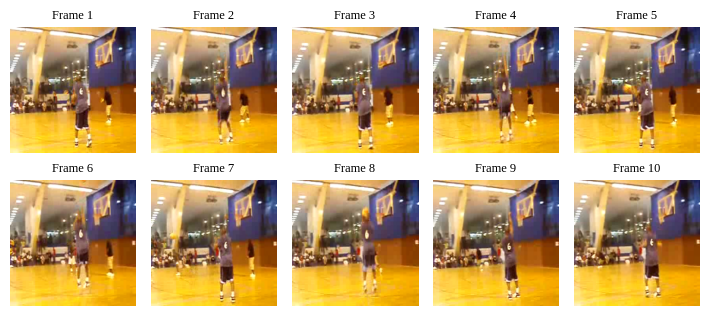

Saved: /content/exp6/figures/plot7_video_frames.eps
Video shown: v_Basketball_g12_c01.avi


In [35]:
# P6 CELL 5 - PLOT 7 (sample frames): shows the 10 uniformly sampled frames of one training video (the first video of
# PLOT7_CLASS) in a 2x5 grid. Saved as plot7_video_frames.eps
PLOT7_CLASS = 0
p7_path = next(p for p, l in splits['train'] if l == PLOT7_CLASS)
p7_frames = read_frames(p7_path)

fig, axes = plt.subplots(2, 5, figsize=(7.2, 3.3))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(p7_frames[i])
    ax.set_title(f'Frame {i + 1}', fontsize=9)
    ax.axis('off')
fig.tight_layout()
save_fig(fig, 'plot7_video_frames')
print('Video shown:', os.path.basename(p7_path))

In [36]:
# P6 CELL 6 - TRAIN THE CNN-LSTM AND CNN-GRU (section 21): the recurrent layer (32 units) reads the (10, D) feature
# sequence, followed by Dropout and a softmax Dense layer. Both models use identical features and settings; results,
# confusion matrices and predicted probabilities on the test set are stored. SELECTED picks the model for Plots 8-9.
def build_video_model(kind):
    rec = layers.LSTM if kind == 'LSTM' else layers.GRU
    m = keras.Sequential([
        keras.Input(shape=(N_FRAMES, D)),
        rec(V_UNITS),
        layers.Dropout(V_DROPOUT),
        layers.Dense(len(CLASSES), activation='softmax'),
    ], name=f'cnn_{kind.lower()}')
    m.compile(optimizer=keras.optimizers.Adam(V_LR), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

v_hist, v_time, v_res, v_cm, v_probs, v_models = {}, {}, {}, {}, {}, {}
for kind in ['LSTM', 'GRU']:
    keras.utils.set_random_seed(SEED)
    m = build_video_model(kind)
    print(f'\n===== CNN-{kind}: trainable parameters = {m.count_params():,} =====')
    t0 = time.perf_counter()
    h = m.fit(Xv_train, yv_train, validation_data=(Xv_val, yv_val),
              epochs=V_EPOCHS, batch_size=V_BATCH, shuffle=True, verbose=2)
    v_time[kind] = time.perf_counter() - t0
    v_hist[kind] = {k: [float(x) for x in vals] for k, vals in h.history.items()}
    probs = m.predict(Xv_test, verbose=0)
    pred = probs.argmax(axis=1)
    p, r, f1, _ = precision_recall_fscore_support(yv_test, pred, average='macro', zero_division=0)
    v_res[kind] = {'Accuracy (%)': accuracy_score(yv_test, pred) * 100, 'Precision (%)': p * 100,
                   'Recall (%)': r * 100, 'F1 (%)': f1 * 100,
                   'Parameters': int(m.count_params()), 'Training Time (s)': v_time[kind]}
    v_cm[kind] = confusion_matrix(yv_test, pred, labels=range(len(CLASSES)))
    v_probs[kind] = probs
    v_models[kind] = m
    m.save(os.path.join(MODEL_DIR, f'video_cnn_{kind.lower()}.keras'))

SELECTED = 'LSTM'                                                 # architecture shown in Plots 8 and 9
print('\nTest results:')
print(pd.DataFrame(v_res).T.round(2).to_string())


===== CNN-LSTM: trainable parameters = 168,196 =====
Epoch 1/30
20/20 - 2s - 116ms/step - accuracy: 0.6903 - loss: 0.9225 - val_accuracy: 0.8090 - val_loss: 0.6281
Epoch 2/30
20/20 - 0s - 17ms/step - accuracy: 0.9161 - loss: 0.3663 - val_accuracy: 0.8315 - val_loss: 0.4931
Epoch 3/30
20/20 - 0s - 16ms/step - accuracy: 0.9419 - loss: 0.2275 - val_accuracy: 0.8764 - val_loss: 0.5151
Epoch 4/30
20/20 - 0s - 18ms/step - accuracy: 0.9710 - loss: 0.1745 - val_accuracy: 0.8652 - val_loss: 0.4497
Epoch 5/30
20/20 - 0s - 17ms/step - accuracy: 0.9871 - loss: 0.1201 - val_accuracy: 0.8539 - val_loss: 0.4922
Epoch 6/30
20/20 - 0s - 17ms/step - accuracy: 0.9806 - loss: 0.1044 - val_accuracy: 0.8652 - val_loss: 0.5790
Epoch 7/30
20/20 - 1s - 27ms/step - accuracy: 0.9935 - loss: 0.0662 - val_accuracy: 0.8764 - val_loss: 0.3943
Epoch 8/30
20/20 - 1s - 35ms/step - accuracy: 1.0000 - loss: 0.0401 - val_accuracy: 0.8764 - val_loss: 0.5465
Epoch 9/30
20/20 - 1s - 34ms/step - accuracy: 1.0000 - loss: 0.02

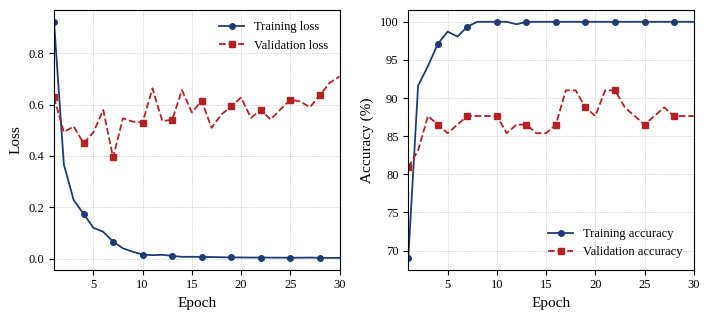

Saved: /content/exp6/figures/plot8_video_curves_lstm.eps


In [37]:
# P6 CELL 7 - PLOT 8 (video training/validation curves): loss (left) and accuracy in % (right) per epoch for the
# selected recurrent architecture. Saved as plot8_video_curves_lstm.eps (or _gru if SELECTED is changed).
h = v_hist[SELECTED]
ep = np.arange(1, len(h['loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.3))
axes[0].plot(ep, h['loss'], '-o', color='#1f3b73', markevery=3, markersize=4, linewidth=1.3, label='Training loss')
axes[0].plot(ep, h['val_loss'], '--s', color='#b22222', markevery=3, markersize=4, linewidth=1.3, label='Validation loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(frameon=False)
axes[1].plot(ep, np.array(h['accuracy']) * 100, '-o', color='#1f3b73', markevery=3, markersize=4, linewidth=1.3, label='Training accuracy')
axes[1].plot(ep, np.array(h['val_accuracy']) * 100, '--s', color='#b22222', markevery=3, markersize=4, linewidth=1.3, label='Validation accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(frameon=False, loc='lower right')
for a in axes:
    a.set_xlim(1, len(ep))
fig.tight_layout()
save_fig(fig, f'plot8_video_curves_{SELECTED.lower()}')

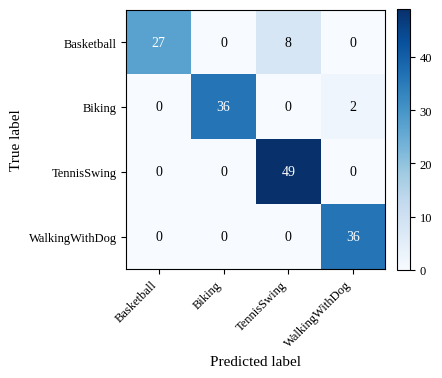

Saved: /content/exp6/figures/plot9_video_confusion_lstm.eps
Per-class recall (CNN-LSTM):
  Basketball        77.1%
  Biking            94.7%
  TennisSwing      100.0%
  WalkingWithDog   100.0%
Most confused pairs: ['Basketball <-> TennisSwing (8)', 'Biking <-> WalkingWithDog (2)']
                precision    recall  f1-score   support

    Basketball      1.000     0.771     0.871        35
        Biking      1.000     0.947     0.973        38
   TennisSwing      0.860     1.000     0.925        49
WalkingWithDog      0.947     1.000     0.973        36

      accuracy                          0.937       158
     macro avg      0.952     0.930     0.935       158
  weighted avg      0.944     0.937     0.935       158

Example predictions (confidence taken from the trained model output):

Video           : v_TennisSwing_g07_c05.avi
Predicted class : TennisSwing
Actual class    : TennisSwing
Confidence      : 1.00

Video           : v_Biking_g07_c02.avi
Predicted class : Biking
Actu

In [38]:
# P6 CELL 8 - PLOT 9 + CLASS-LEVEL ANALYSIS + EXAMPLE PREDICTIONS: draws the video confusion matrix, prints per-class
# recall and the most-confused class pairs, and shows five random test videos as "Predicted / Actual / Confidence"
# where the confidence is the model's own softmax output (never typed in manually), as required in section 19.
def plot_confusion(cm, labels, name):
    n = len(labels)
    fig, ax = plt.subplots(figsize=(4.4, 3.9))
    im = ax.imshow(cm, cmap='Blues', vmin=0)
    ax.set_xticks(range(n)); ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticks(range(n)); ax.set_yticklabels(labels)
    ax.grid(False)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=10,
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
    ax.set_xlabel('Predicted label'); ax.set_ylabel('True label')
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cb.ax.grid(False)
    fig.tight_layout()
    save_fig(fig, name)

plot_confusion(v_cm[SELECTED], CLASSES, f'plot9_video_confusion_{SELECTED.lower()}')

cm = v_cm[SELECTED]
rec = cm.diagonal() / cm.sum(axis=1) * 100
print(f'Per-class recall (CNN-{SELECTED}):')
for c, r_ in zip(CLASSES, rec):
    print(f'  {c:<16}{r_:6.1f}%')
pairs = sorted([(cm[i, j] + cm[j, i], i, j) for i in range(len(CLASSES)) for j in range(i + 1, len(CLASSES))
                if cm[i, j] + cm[j, i] > 0], reverse=True)
print('Most confused pairs:', [f'{CLASSES[i]} <-> {CLASSES[j]} ({t})' for t, i, j in pairs[:3]] or 'none')
print(classification_report(yv_test, v_probs[SELECTED].argmax(1), target_names=CLASSES, digits=3, zero_division=0))

print('Example predictions (confidence taken from the trained model output):')
rng_p = np.random.default_rng(SEED)
for i in rng_p.choice(len(yv_test), size=min(5, len(yv_test)), replace=False):
    pr = v_probs[SELECTED][i]
    print(f'\nVideo           : {test_names[i]}')
    print(f'Predicted class : {CLASSES[pr.argmax()]}')
    print(f'Actual class    : {CLASSES[yv_test[i]]}')
    print(f'Confidence      : {pr.max():.2f}')

In [39]:
# P6 CELL 9 - RESULTS FOR THE CONSOLIDATED TABLE (section 25): accuracy, macro precision/recall/F1, trainable parameters
# and training time for CNN-LSTM and CNN-GRU, saved to video_results.csv for Part 8.
tbl = pd.DataFrame(v_res).T
tbl.index = [f'CNN-{k}' for k in tbl.index]
tbl.to_csv(os.path.join(DATA_DIR, 'video_results.csv'))
print(tbl.round(2).to_string())
print('\nNote: Parameters = trainable parameters of the recurrent head only; the frozen MobileNetV2 has',
      f'{cnn.count_params():,} additional (untrained) parameters.')

          Accuracy (%)  Precision (%)  Recall (%)  F1 (%)  Parameters  Training Time (s)
CNN-LSTM         93.67          95.18       92.97   93.54    168196.0              13.76
CNN-GRU          92.41          93.88       91.62   92.27    126276.0              14.90

Note: Parameters = trainable parameters of the recurrent head only; the frozen MobileNetV2 has 2,257,984 additional (untrained) parameters.


In [40]:
# P6 CELL 10 - DOES THE RECURRENT MODEL USE TEMPORAL ORDER? Re-evaluates the trained model on test videos whose 10
# frame features are randomly shuffled in time. If accuracy barely changes, the classifier is mostly relying on
# per-frame appearance rather than on temporal order - useful evidence for your "role of the recurrent model" inference.
rng_s = np.random.default_rng(SEED)
m = v_models[SELECTED]
acc_orig = accuracy_score(yv_test, m.predict(Xv_test, verbose=0).argmax(1)) * 100
acc_shuf = []
for _ in range(5):
    Xs = np.stack([x[rng_s.permutation(N_FRAMES)] for x in Xv_test])
    acc_shuf.append(accuracy_score(yv_test, m.predict(Xs, verbose=0).argmax(1)) * 100)
print(f'Test accuracy, frames in true order      : {acc_orig:.2f}%')
print(f'Test accuracy, frames shuffled (5 trials): {np.mean(acc_shuf):.2f}% +/- {np.std(acc_shuf):.2f}')

Test accuracy, frames in true order      : 93.67%
Test accuracy, frames shuffled (5 trials): 93.54% +/- 0.25


In [41]:
# P7 CELL 1 - SETUP + DATA: generates the synthetic reversal dataset (section 22). Input [a,b,c,d,e] -> target [e,d,c,b,a].
# Token 0 is the START token, real tokens are 1-9. For teacher forcing the decoder input is [START, y1, ..., y(L-1)].
S_LEN, S_MAXV, S_N = 5, 9, 8000
S_VOCAB = S_MAXV + 1                                              # 0 = START, 1..9 = data
S_EMB, S_UNITS, S_LR, S_BATCH, S_EPOCHS = 16, 64, 1e-3, 64, 40

rng_s2s = np.random.default_rng(SEED)
X_all = rng_s2s.integers(1, S_MAXV + 1, size=(S_N, S_LEN))
Y_all = X_all[:, ::-1].copy()                                     # reversed sequence = target
D_all = np.concatenate([np.zeros((S_N, 1), dtype=int), Y_all[:, :-1]], axis=1)   # decoder input (teacher forcing)

n_tr, n_va = int(0.70 * S_N), int(0.15 * S_N)
sl = {'train': slice(0, n_tr), 'val': slice(n_tr, n_tr + n_va), 'test': slice(n_tr + n_va, S_N)}
Xs_tr, Ds_tr, Ys_tr = X_all[sl['train']], D_all[sl['train']], Y_all[sl['train']]
Xs_va, Ds_va, Ys_va = X_all[sl['val']],   D_all[sl['val']],   Y_all[sl['val']]
Xs_te, Ds_te, Ys_te = X_all[sl['test']],  D_all[sl['test']],  Y_all[sl['test']]

print(f'Sequence length: {S_LEN} | value range: 1-{S_MAXV} | vocabulary size (with START): {S_VOCAB}')
print(f'Train/Val/Test sequences: {len(Xs_tr)} / {len(Xs_va)} / {len(Xs_te)}')
print('Encoder input shape :', Xs_tr.shape, '| Decoder input shape:', Ds_tr.shape, '| Target shape:', Ys_tr.shape)
print('\nExample pair:')
print('  Input          :', Xs_tr[0].tolist())
print('  Decoder input  :', Ds_tr[0].tolist(), '(START + shifted target)')
print('  Target         :', Ys_tr[0].tolist())

Sequence length: 5 | value range: 1-9 | vocabulary size (with START): 10
Train/Val/Test sequences: 5600 / 1200 / 1200
Encoder input shape : (5600, 5) | Decoder input shape: (5600, 5) | Target shape: (5600, 5)

Example pair:
  Input          : [1, 7, 6, 4, 4]
  Decoder input  : [0, 4, 4, 6, 7] (START + shifted target)
  Target         : [4, 4, 6, 7, 1]


In [42]:
# P7 CELL 2 - MODEL (section 22): encoder LSTM compresses the input into the context state (h, c); the decoder LSTM is
# initialised with that state and produces the output sequence one step at a time. The layers are kept as named objects
# so the same trained weights can be reused for step-by-step inference in Cell 4.
enc_in = keras.Input(shape=(S_LEN,), name='encoder_input')
enc_emb_layer = layers.Embedding(S_VOCAB, S_EMB, name='enc_embedding')
enc_lstm = layers.LSTM(S_UNITS, return_state=True, name='encoder_lstm')
_, enc_h, enc_c = enc_lstm(enc_emb_layer(enc_in))                 # context = final (h, c)

dec_in = keras.Input(shape=(S_LEN,), name='decoder_input')
dec_emb_layer = layers.Embedding(S_VOCAB, S_EMB, name='dec_embedding')
dec_lstm = layers.LSTM(S_UNITS, return_sequences=True, return_state=True, name='decoder_lstm')
dec_dense = layers.Dense(S_VOCAB, activation='softmax', name='decoder_softmax')
dec_seq, _, _ = dec_lstm(dec_emb_layer(dec_in), initial_state=[enc_h, enc_c])
dec_out = dec_dense(dec_seq)

s2s = keras.Model([enc_in, dec_in], dec_out, name='seq2seq_reversal')
s2s.compile(optimizer=keras.optimizers.Adam(S_LR), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
s2s.summary()

Model: "seq2seq_reversal"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_embedding       │ (None, 5, 16)     │        160 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_embedding       │ (None, 5, 16)     │        160 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 64),      │     20,736 │ enc_embedding[0]… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 5, 64),   │     20,736 │ dec_embedding[0]… │
│                     │ (None, 64),       │            │ encoder_lstm[0][… │
│                     │ (None, 64)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_softmax     │ (None, 5, 10)     │        650 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 42,442 (165.79 KB)

 Trainable params: 42,442 (165.79 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# P7 CELL 3 - TRAIN with teacher forcing: the decoder is fed the TRUE previous target token at every step.
# Training/validation loss per epoch are stored for the report.
keras.utils.set_random_seed(SEED)
t0 = time.perf_counter()
h_s2s = s2s.fit([Xs_tr, Ds_tr], Ys_tr, validation_data=([Xs_va, Ds_va], Ys_va),
                epochs=S_EPOCHS, batch_size=S_BATCH, shuffle=True, verbose=2)
s2s_time = time.perf_counter() - t0
s2s.save(os.path.join(MODEL_DIR, 's2s_reversal.keras'))
print(f'\nTraining time: {s2s_time:.1f} s | parameters: {s2s.count_params():,}')
print(f"Final training loss  : {h_s2s.history['loss'][-1]:.4f}")
print(f"Final validation loss: {h_s2s.history['val_loss'][-1]:.4f}")

Epoch 1/40
88/88 - 7s - 78ms/step - accuracy: 0.2404 - loss: 2.0483 - val_accuracy: 0.3450 - val_loss: 1.7139
Epoch 2/40
88/88 - 1s - 11ms/step - accuracy: 0.4527 - loss: 1.4162 - val_accuracy: 0.6345 - val_loss: 1.0118
Epoch 3/40
88/88 - 1s - 14ms/step - accuracy: 0.8075 - loss: 0.6925 - val_accuracy: 0.9152 - val_loss: 0.4558
Epoch 4/40
88/88 - 1s - 10ms/step - accuracy: 0.9611 - loss: 0.3205 - val_accuracy: 0.9820 - val_loss: 0.2281
Epoch 5/40
88/88 - 1s - 15ms/step - accuracy: 0.9889 - loss: 0.1788 - val_accuracy: 0.9928 - val_loss: 0.1367
Epoch 6/40
88/88 - 1s - 10ms/step - accuracy: 0.9951 - loss: 0.1150 - val_accuracy: 0.9950 - val_loss: 0.0950
Epoch 7/40
88/88 - 1s - 15ms/step - accuracy: 0.9985 - loss: 0.0779 - val_accuracy: 0.9975 - val_loss: 0.0678
Epoch 8/40
88/88 - 2s - 22ms/step - accuracy: 0.9991 - loss: 0.0572 - val_accuracy: 0.9983 - val_loss: 0.0518
Epoch 9/40
88/88 - 2s - 19ms/step - accuracy: 0.9997 - loss: 0.0439 - val_accuracy: 0.9987 - val_loss: 0.0405
Epoch 10/4

In [44]:
# P7 CELL 4 - INFERENCE MODELS + GREEDY DECODING: at test time there is no true target, so the decoder starts from START
# and feeds its own previous prediction back in at every step (no teacher forcing). This is the real generation process.
encoder_model = keras.Model(enc_in, [enc_h, enc_c])

st_h = keras.Input(shape=(S_UNITS,)); st_c = keras.Input(shape=(S_UNITS,))
tok_in = keras.Input(shape=(1,))
d_out, d_h, d_c = dec_lstm(dec_emb_layer(tok_in), initial_state=[st_h, st_c])
decoder_model = keras.Model([tok_in, st_h, st_c], [dec_dense(d_out), d_h, d_c])

def greedy_decode(X):
    h, c = encoder_model.predict(X, verbose=0)
    tok = np.zeros((len(X), 1), dtype=int)                        # START token
    out = []
    for _ in range(S_LEN):
        probs, h, c = decoder_model.predict([tok, h, c], verbose=0)
        tok = probs[:, -1, :].argmax(axis=-1).reshape(-1, 1)
        out.append(tok)
    return np.concatenate(out, axis=1)

Ypred_te = greedy_decode(Xs_te)
print('Decoded test predictions:', Ypred_te.shape)

Decoded test predictions: (1200, 5)


In [45]:
# P7 CELL 5 - EVALUATION (section 24): token accuracy, sequence accuracy, final training/validation loss, per-position
# accuracy, and five test examples in the "Sample / Input / Predicted" format required in section 23.
tok_correct = (Ypred_te == Ys_te)
token_acc = tok_correct.mean() * 100
seq_acc = tok_correct.all(axis=1).mean() * 100
pos_acc = tok_correct.mean(axis=0) * 100

print(f'Token accuracy    : {token_acc:.2f}%')
print(f'Sequence accuracy : {seq_acc:.2f}%')
print(f'Training loss     : {h_s2s.history["loss"][-1]:.4f}')
print(f'Validation loss   : {h_s2s.history["val_loss"][-1]:.4f}')
print('Per-position accuracy (output position 1..L):', [f'{a:.1f}%' for a in pos_acc])
print(f'If errors were independent, sequence accuracy would be about {(token_acc/100) ** S_LEN * 100:.2f}% '
      f'(= token accuracy ^ {S_LEN})')

print('\nExample test predictions:')
print(f"{'Sample':<8}{'Input Sequence':<22}{'Expected':<22}{'Predicted Output':<22}{'Correct'}")
for k, i in enumerate(np.random.default_rng(SEED).choice(len(Xs_te), 5, replace=False), 1):
    ok = 'Yes' if tok_correct[i].all() else 'No'
    print(f'{k:<8}{str(Xs_te[i].tolist()):<22}{str(Ys_te[i].tolist()):<22}{str(Ypred_te[i].tolist()):<22}{ok}')

wrong = np.where(~tok_correct.all(axis=1))[0]
print(f'\nWrongly decoded test sequences: {len(wrong)} of {len(Xs_te)}')
for i in wrong[:3]:
    print('  Input', Xs_te[i].tolist(), '| Expected', Ys_te[i].tolist(), '| Predicted', Ypred_te[i].tolist())

Token accuracy    : 100.00%
Sequence accuracy : 100.00%
Training loss     : 0.0013
Validation loss   : 0.0015
Per-position accuracy (output position 1..L): ['100.0%', '100.0%', '100.0%', '100.0%', '100.0%']
If errors were independent, sequence accuracy would be about 100.00% (= token accuracy ^ 5)

Example test predictions:
Sample  Input Sequence        Expected              Predicted Output      Correct
1       [4, 2, 7, 5, 8]       [8, 5, 7, 2, 4]       [8, 5, 7, 2, 4]       Yes
2       [4, 7, 5, 1, 2]       [2, 1, 5, 7, 4]       [2, 1, 5, 7, 4]       Yes
3       [5, 2, 1, 2, 1]       [1, 2, 1, 2, 5]       [1, 2, 1, 2, 5]       Yes
4       [8, 6, 1, 1, 3]       [3, 1, 1, 6, 8]       [3, 1, 1, 6, 8]       Yes
5       [4, 1, 8, 1, 2]       [2, 1, 8, 1, 4]       [2, 1, 8, 1, 4]       Yes

Wrongly decoded test sequences: 0 of 1200


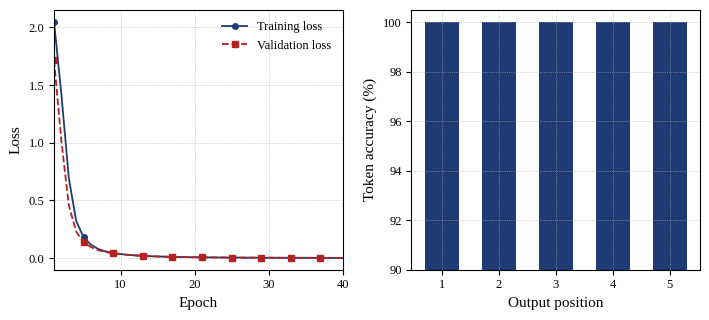

Saved: /content/exp6/figures/plot10_seq2seq_curves.eps


In [46]:
# P7 CELL 6 - LOSS CURVES + PER-POSITION ACCURACY: left = training/validation loss per epoch; right = free-running
# accuracy for each output position. Saved as plot10_seq2seq_curves.eps. (Supports the token vs sequence accuracy inference.)
ep = np.arange(1, len(h_s2s.history['loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.3))
axes[0].plot(ep, h_s2s.history['loss'], '-o', color='#1f3b73', markevery=4, markersize=4, linewidth=1.3, label='Training loss')
axes[0].plot(ep, h_s2s.history['val_loss'], '--s', color='#b22222', markevery=4, markersize=4, linewidth=1.3, label='Validation loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(frameon=False); axes[0].set_xlim(1, len(ep))
axes[1].bar(np.arange(1, S_LEN + 1), pos_acc, color='#1f3b73', width=0.6)
axes[1].set_xlabel('Output position'); axes[1].set_ylabel('Token accuracy (%)')
axes[1].set_xticks(range(1, S_LEN + 1)); axes[1].set_ylim(max(0, pos_acc.min() - 10), 100.5)
fig.tight_layout()
save_fig(fig, 'plot10_seq2seq_curves')

In [47]:
# P7 CELL 7 - RESULTS TABLE for the report/Part 8: the separate seq2seq table required in section 25.
s2s_tbl = pd.DataFrame([{
    'Token Accuracy (%)': token_acc, 'Sequence Accuracy (%)': seq_acc,
    'Training Loss': h_s2s.history['loss'][-1], 'Validation Loss': h_s2s.history['val_loss'][-1],
    'Parameters': int(s2s.count_params()), 'Training Time (s)': s2s_time}], index=['Encoder-Decoder LSTM'])
s2s_tbl.to_csv(os.path.join(DATA_DIR, 'seq2seq_results.csv'))
print(s2s_tbl.round(3).to_string())

                      Token Accuracy (%)  Sequence Accuracy (%)  Training Loss  Validation Loss  Parameters  Training Time (s)
Encoder-Decoder LSTM               100.0                  100.0          0.001            0.002       42442              50.65
